In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("TSLA_Stock.csv")

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print(f"\nColumns: {list(data.columns)}")
print(f"\nMissing values: {data.isnull().sum().sum()}")


DATASET OVERVIEW
Shape: 254 rows, 7 columns
Date range: 2021-03-23 to 2022-03-23

Columns: ['Unnamed: 0', 'Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Missing values: 0


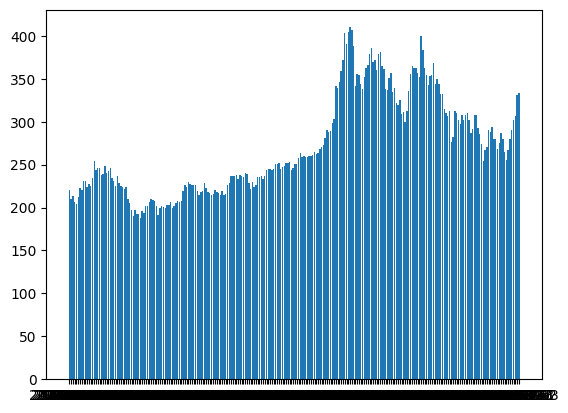

In [20]:
x = data["Date"]
y = data["Close"]

fig, ax = plt.subplots()
ax.bar(x, y)

plt.show()

In [19]:
# MACD (Moving Average Convergence Divergence)
ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
data['macd'] = ema_12 - ema_26
data['macd_signal'] = data['macd'].ewm(span=9, adjust=False).mean()
data['macd_histogram'] = data['macd'] - data['macd_signal']